First Five Rows:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



Dataset Shape: (614, 13)

Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Default KNN Accuracy: 0.7561

Accuracy for Different K values
K = 3 --> Accuracy = 0.7480
K = 5 --> Accuracy = 0.7561
K = 7 --> Accuracy = 0.7805

Best K: {'n_neighbors': 13}
Best Cross Validation Accuracy: 0.8004

Test Accuracy After Tuning: 0.7886

Confusion Matrix:
[[17 26]
 [ 0 80]]


<Figure size 600x500 with 0 Axes>

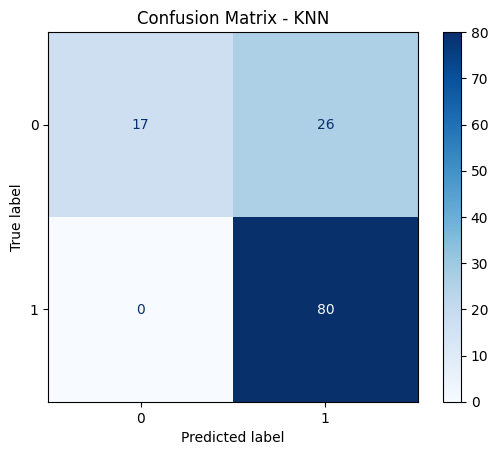

In [1]:
# ==========================================
# K-Nearest Neighbors (KNN) - Loan Approval Prediction
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("train_u6lujuX_CVtuZ9i.csv")

print("First Five Rows:")
display(df.head())

print("\nDataset Shape:", df.shape)

# ==========================================
# Check Missing Values
# ==========================================

print("\nMissing Values:")
print(df.isnull().sum())

# ==========================================
# Fill Missing Values
# ==========================================

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Numerical -> Median
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical -> Mode
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# ==========================================
# Encode Categorical Variables
# ==========================================

encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

# ==========================================
# Features and Target
# ==========================================

X = df.drop("Loan_Status", axis=1)

# Loan_ID is only an identifier
if "Loan_ID" in X.columns:
    X = X.drop("Loan_ID", axis=1)

y = df["Loan_Status"]

# ==========================================
# Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# Train Default KNN Model
# ==========================================

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nDefault KNN Accuracy:", round(accuracy,4))

# ==========================================
# Experiment with Different K values
# ==========================================

print("\nAccuracy for Different K values")

k_values = [3,5,7]

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test,pred)
    print(f"K = {k} --> Accuracy = {acc:.4f}")

# ==========================================
# Hyperparameter Tuning
# ==========================================

param_grid = {
    'n_neighbors':[3,5,7,9,11,13,15]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train,y_train)

print("\nBest K:", grid.best_params_)
print("Best Cross Validation Accuracy:", round(grid.best_score_,4))

best_knn = grid.best_estimator_

best_pred = best_knn.predict(X_test)

best_accuracy = accuracy_score(y_test,best_pred)

print("\nTest Accuracy After Tuning:", round(best_accuracy,4))

# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test,best_pred)

print("\nConfusion Matrix:")
print(cm)

# ==========================================
# Visualization
# ==========================================

plt.figure(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_knn.classes_
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix - KNN")
plt.show()